# Visualizing the ZINC Toxicity Dataset
This notebook verifies our custom graph-classification dataset. Our goal is to:
1. Confirm the dataset is perfectly balanced (50% Class 0, 50% Class 1).
2. Check the distribution of our train/val/test/eap splits.
3. Visualize the PyG tensors as chemical graphs to verify that Class 1 molecules actually contain Nitrogen (N) and Oxygen (O) atoms indicative of our $NO_2$ or $NH_2$ groups.

In [1]:
import os
import sys
import yaml
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

sys.path.append(os.path.abspath('..'))
from src.data.factory import get_dataset

torch.manual_seed(42)

In [2]:
import os
import sys
import yaml

project_root = os.path.abspath('..')
sys.path.append(project_root)

from src.data.factory import get_dataset

config_path = os.path.join(project_root, 'config/dataset', 'zinc_no2.yaml')
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

dataset_path = os.path.join(project_root, 'data', config['dataset']['name'])

config['dataset']['root_dir'] = dataset_path

dataset = get_dataset(config)

print(f"Successfully loaded {len(dataset)} molecular graphs.")

[Dataset] Found processed zinc_no2 at /home/nikodem/Workspace/3-sem-mgr/eapgt/data/zinc_no2/processed/zinc_no2_data.pt. Loading from disk...
Successfully loaded 10826 molecular graphs.


In [3]:
labels = []
splits = []
num_nodes = []
num_edges = []

for data in dataset:
    labels.append(data.y.item())
    splits.append(data.split_mask.item())
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges / 2) 

labels = np.array(labels)
splits = np.array(splits)

print("--- Dataset Statistics ---")
print(f"Class 0 (Clean): {np.sum(labels == 0)} graphs")
print(f"Class 1 (Toxic/Alert): {np.sum(labels == 1)} graphs")
print("-" * 25)
print(f"Train Split (0): {np.sum(splits == 0)}")
print(f"Val Split   (1): {np.sum(splits == 1)}")
print(f"Test Split  (2): {np.sum(splits == 2)}")
print(f"EAP Split   (3): {np.sum(splits == 3)}")
print("-" * 25)
print(f"Average Nodes per graph: {np.mean(num_nodes):.1f}")
print(f"Average Edges per graph: {np.mean(num_edges):.1f}")

--- Dataset Statistics ---
Class 0 (Clean): 5413 graphs
Class 1 (Toxic/Alert): 5413 graphs
-------------------------
Train Split (0): 7578
Val Split   (1): 1082
Test Split  (2): 1082
EAP Split   (3): 1084
-------------------------
Average Nodes per graph: 42.2
Average Edges per graph: 43.8


In [4]:
def plot_molecule(data, title):
    element_map = {
        1: ('H', 'lightblue'), 
        6: ('C', 'lightgray'),
        7: ('N', '#1f77b4'),  # Blue
        8: ('O', '#d62728'),  # Red
        9: ('F', 'green'),
        15: ('P', 'orange'),
        16: ('S', 'yellow'),
        17: ('Cl', 'lightgreen'),
    }
    
    G = to_networkx(data, to_undirected=True)
    
    node_colors = []
    labels = {}
    
    for i in range(data.num_nodes):
        atomic_num = int(data.x[i][0].item())
        symbol, color = element_map.get(atomic_num, ('?', 'white'))
        node_colors.append(color)
        labels[i] = symbol
        
    plt.figure(figsize=(6, 6))
    pos = nx.kamada_kawai_layout(G)
    
    nx.draw(
        G, pos, 
        node_color=node_colors, 
        with_labels=True, 
        labels=labels,
        node_size=600, 
        font_weight='bold',
        font_color='black',
        edge_color='gray',
        width=2.0
    )
    plt.title(title, fontsize=14)
    plt.show()

--- Class 0 (Clean) ---
SMILES: CCNC(=O)c1ccc(NCCOc2ccccc2)[nH+]n1



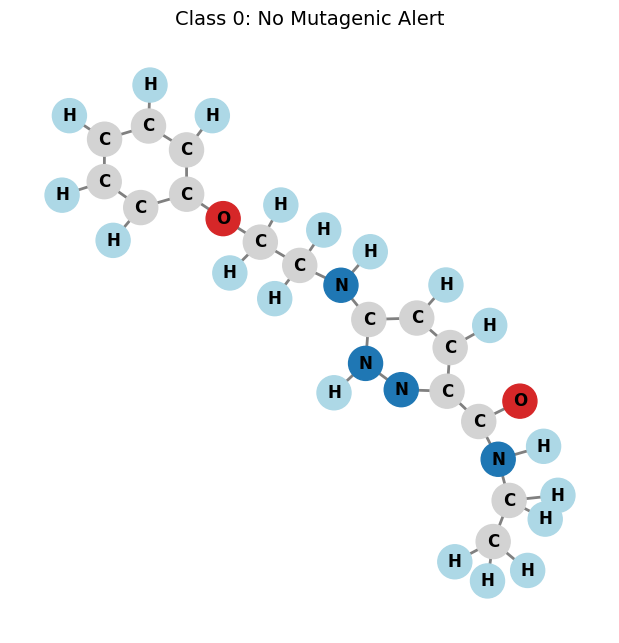


--- Class 1 (Toxic) ---
SMILES: C[NH+](C)CCCNc1cc(Cl)c(Cl)cc1N



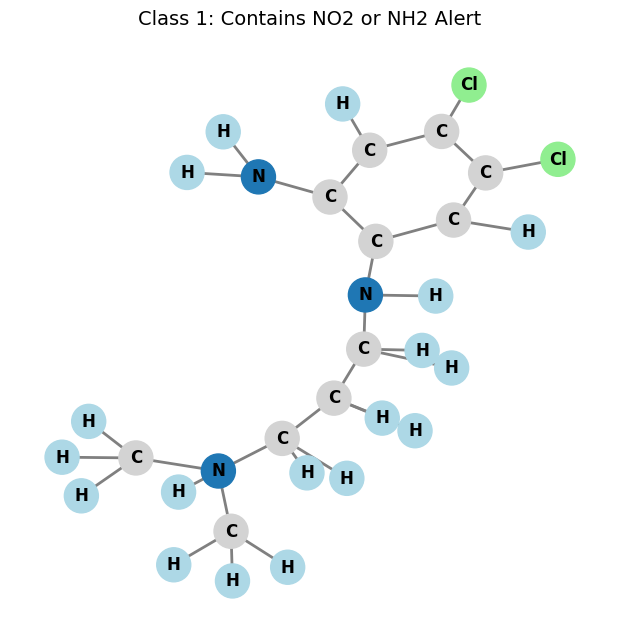

In [5]:
class_0_idx = next(i for i, data in enumerate(dataset) if data.y.item() == 0)
class_1_idx = next(i for i, data in enumerate(dataset) if data.y.item() == 1)

class_0_graph = dataset[class_0_idx]
class_1_graph = dataset[class_1_idx]

print("--- Class 0 (Clean) ---")
print(f"SMILES: {dataset.smiles_list[class_0_idx]}")
plot_molecule(class_0_graph, "Class 0: No Mutagenic Alert")

print("\n--- Class 1 (Toxic) ---")
print(f"SMILES: {dataset.smiles_list[class_1_idx]}")
plot_molecule(class_1_graph, "Class 1: Contains NO2 or NH2 Alert")

--- Counterfactual Pair Index: 0 ---


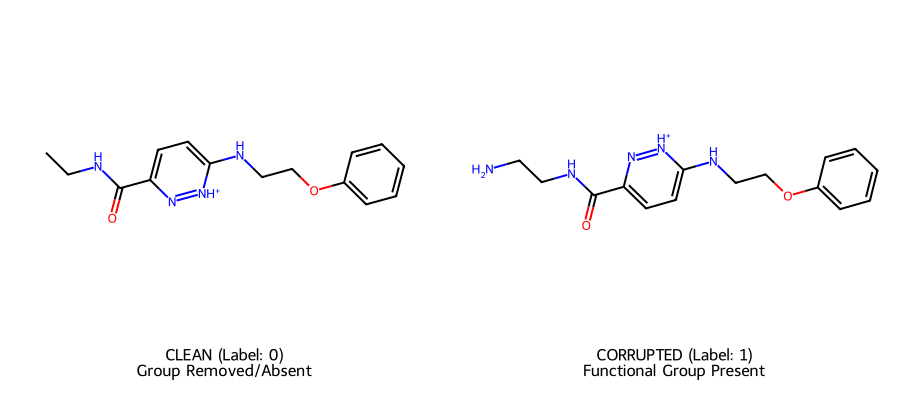

--- Counterfactual Pair Index: 5414 ---


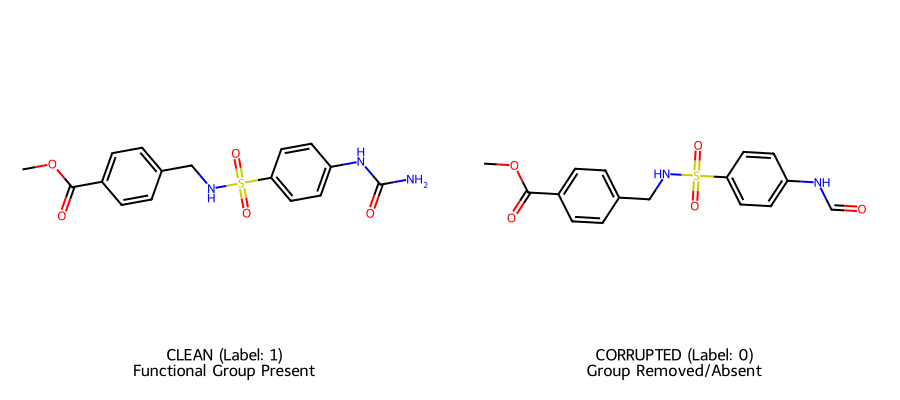

In [6]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

dataset_name = "zinc_no2"
cf_path = f"../data/{dataset_name}/counterfactuals.pt"
pairs = torch.load(cf_path, weights_only=False)

def plot_zinc_pair(index):
    pair = pairs[index]
    clean_data = pair['clean']
    corr_data = pair['corrupted']

    clean_mol = Chem.MolFromSmiles(clean_data.smiles)
    corr_mol = Chem.MolFromSmiles(corr_data.smiles)

    def get_desc(y):
        return "Functional Group Present" if y == 1 else "Group Removed/Absent"
        
    clean_legend = f"CLEAN (Label: {clean_data.y.item()})\n{get_desc(clean_data.y.item())}"
    corr_legend = f"CORRUPTED (Label: {corr_data.y.item()})\n{get_desc(corr_data.y.item())}"

    print(f"--- Counterfactual Pair Index: {index} ---")
    img = Draw.MolsToGridImage(
        [clean_mol, corr_mol], 
        molsPerRow=2, 
        subImgSize=(450, 400), 
        legends=[clean_legend, corr_legend],
        returnPNG=False 
    )
    
    display(img)

plot_zinc_pair(0) 

plot_zinc_pair(len(pairs) // 2 + 1)